# **Pearl-AQI-Engine**: Exploratory Data Analysis (EDA)
**Objective:** Fetch the engineered feature set from the Hopsworks Offline Store and conduct visual analysis to identify correlations, cyclical trends, and target variable behavior before model training.

In [3]:
import hopsworks
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

plt.style.use('dark_background')
sns.set_palette(["#39ff14"])
plt.rcParams['axes.facecolor'] = '#1a1a1a'
plt.rcParams['figure.facecolor'] = '#1a1a1a'

In [ ]:
!pip install hopsworks==4.7.*

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.2/763.2 kB 10.5 MB/s eta 0:00:00
  Attempting uninstall: hopsworks
    Found existing installation: hopsworks 4.8.2
    Uninstalling hopsworks-4.8.2:
      Successfully uninstalled hopsworks-4.8.2


### 1. **Data Ingestion from Feature Store**
Connecting directly to the Hopsworks Offline Store. Feature stores do not guarantee chronological row ordering upon retrieval, so a time-based sort is mandatory after fetching.

In [14]:
hw_api_key = userdata.get('HOPSWORKS_API_KEY')
project = hopsworks.login(api_key_value=hw_api_key)
fs = project.get_feature_store()

weather_fg = fs.get_feature_group(name="pearl_weather_features_v1", version=1)

#pull data via the Storage Preview Engine , bypasses broken Arrow servers
print("Fetching clean dataset snapshot...")
df = weather_fg.show(500)

df = df.sort_values('time').reset_index(drop=True)
print(f"Success! Loaded {len(df)} hourly records.")
df.head()


Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32889
Fetching clean dataset snapshot...
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.24s) 
Success! Loaded 500 hourly records.


,time,european_aqi,pm10,pm2_5,nitrogen_dioxide,hour,day_of_week,month,aqi_momentum
0,2026-02-08 00:00:00+00:00,65,21.9,20.0,10.2,0,6,2,0.0
1,2026-02-08 01:00:00+00:00,65,20.0,17.6,18.4,1,6,2,0.0
2,2026-02-08 03:00:00+00:00,64,27.1,24.8,35.9,3,6,2,-1.0
3,2026-02-08 20:00:00+00:00,66,52.3,50.3,78.3,20,6,2,0.0
4,2026-02-09 02:00:00+00:00,69,28.0,26.6,40.4,2,0,2,0.0


### 2. **Time-Series Visualization**
Visualizing the primary target variable (`european_aqi`) over our 90-day window to identify volatility and macro-trends.

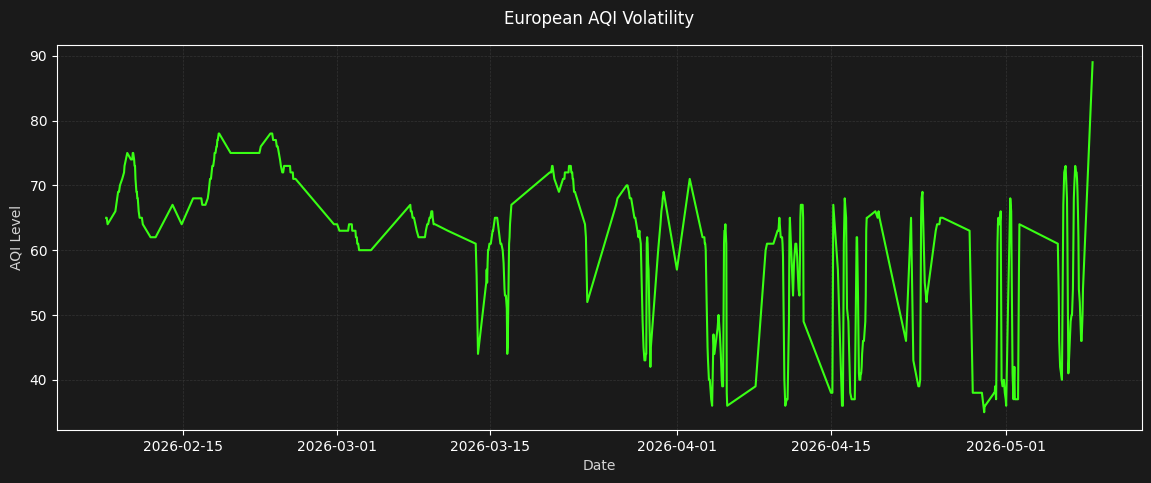

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(df['time'], df['european_aqi'], color='#39ff14', linewidth=1.5)

plt.title("European AQI Volatility", color='white', pad=15)
plt.xlabel("Date", color='lightgray')
plt.ylabel("AQI Level", color='lightgray')
plt.grid(color='#333333', linestyle='--', linewidth=0.5)

plt.show()

### 3. **Feature Correlation Analysis**
Machine learning models rely heavily on feature correlation. This heatmap exposes linear relationships between our engineered temporal features (`hour`, `month`), pollutants (`pm10`, `pm2_5`), and our momentum feature.

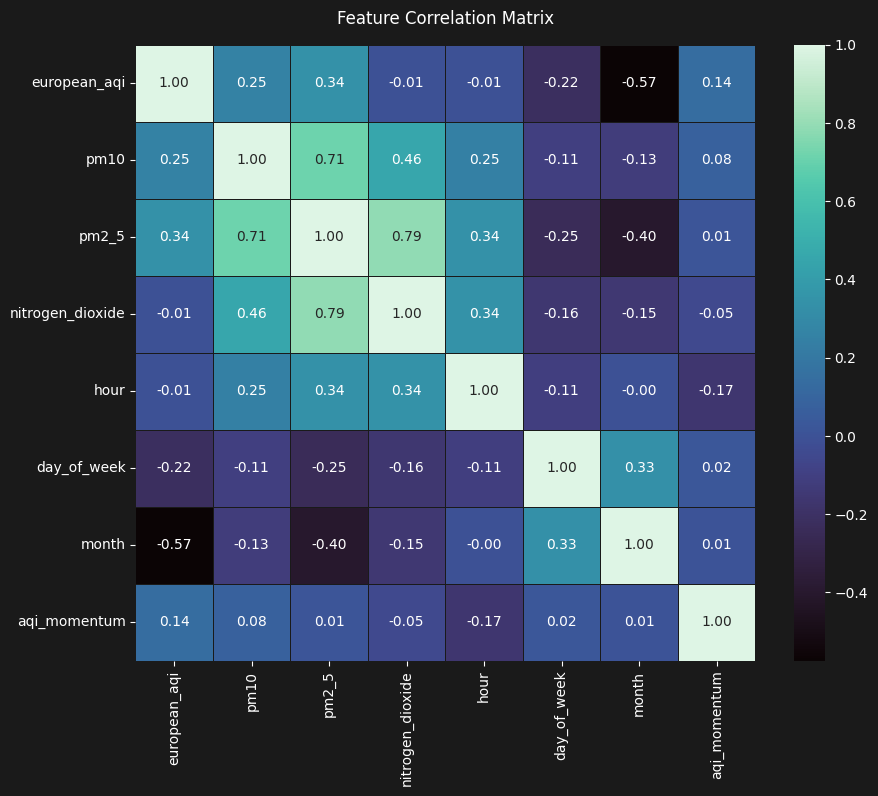

In [17]:
numeric_df = df.drop(columns=['time'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="mako", fmt=".2f", linewidths=0.5, linecolor='#1a1a1a')

plt.title("Feature Correlation Matrix", color='white', pad=15)
plt.show()